# Meteo: Air temperature (TA) (2005-2025)

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# Variable

In [1]:
varname = 'TA_T1_47_1_gfXG'
var = "TA"  # Name shown in plots
units = "°C"

# Imports

In [2]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import diive as dv
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.cumulative import CumulativeYear
from diive.core.plotting.bar import LongtermAnomaliesYear

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.91.0


# Load data

In [3]:
# Gap-filled TA produced by notebook 10_METEO/02. Data files live in the external
# (untracked) data folder, mirroring the workflow tree of this repo.
SOURCEDIR = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"
FILENAME = r"02_METEO_TA_GAPFILLED_2004-2025.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)

# The source product starts in 2004, this overview covers 2005-2025.
keeplocs = (df.index.year >= 2005) & (df.index.year <= 2025)
df = df[keeplocs].copy()

# The product carries a fill flag alongside the values: 0 = observed, > 0 = gap-filled.
print(f"Columns: {list(df.columns)}")
print(f"Range:   {df.index[0]} -> {df.index[-1]} ({len(df):,} records)")
df

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\02_METEO
_TA_GAPFILLED_2004-2025.parquet (0.048 seconds).

Columns: ['TA_T1_47_1_gfXG', 'FLAG_TA_T1_47_1_ISFILLED']
Range:   2005-01-01 00:15:00 -> 2025-12-31 23:45:00 (368,160 records)


,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED
TIMESTAMP_MIDDLE,,
2005-01-01 00:15:00,-2.160000,0
2005-01-01 00:45:00,-2.010000,0
2005-01-01 01:15:00,-1.791000,0
2005-01-01 01:45:00,-1.539000,0
2005-01-01 02:15:00,-1.338000,0
...,...,...
2025-12-31 21:45:00,-3.081644,0
2025-12-31 22:15:00,-3.084372,0
2025-12-31 22:45:00,-3.423939,0


In [4]:
series = df[varname].copy()
series

TIMESTAMP_MIDDLE
2005-01-01 00:15:00   -2.160000
2005-01-01 00:45:00   -2.010000
2005-01-01 01:15:00   -1.791000
2005-01-01 01:45:00   -1.539000
2005-01-01 02:15:00   -1.338000
                         ...   
2025-12-31 21:45:00   -3.081644
2025-12-31 22:15:00   -3.084372
2025-12-31 22:45:00   -3.423939
2025-12-31 23:15:00   -3.437078
2025-12-31 23:45:00   -3.546789
Freq: 30min, Name: TA_T1_47_1_gfXG, Length: 368160, dtype: float64

In [5]:
xlabel = f"{var} ({units})"
xlim = [series.min(), series.max()]

</br>

# Stats

## Overall mean

In [6]:
_yearly_avg = series.resample('YE').mean()
_overall_mean = _yearly_avg.mean()
_overall_sd = _yearly_avg.std()
print(f"Overall mean: {_overall_mean} +/- {_overall_sd}")

Overall mean: 9.018720771635815 +/- 1.348367773593637


## Yearly means

In [7]:
ym = series.resample('YE').mean()
ym

TIMESTAMP_MIDDLE
2005-12-31     7.428936
2006-12-31     7.959663
2007-12-31     8.109265
2008-12-31     7.588625
2009-12-31     7.941024
2010-12-31     6.822336
2011-12-31     8.787186
2012-12-31     7.755105
2013-12-31     7.107060
2014-12-31     8.703548
2015-12-31     8.736438
2016-12-31     9.657462
2017-12-31     9.759068
2018-12-31    10.702271
2019-12-31    10.344697
2020-12-31    10.504883
2021-12-31     9.056597
2022-12-31    11.120893
2023-12-31    10.764881
2024-12-31    10.321057
2025-12-31    10.222141
Freq: YE-DEC, Name: TA_T1_47_1_gfXG, dtype: float64

In [8]:
ym.sort_values(ascending=False)

TIMESTAMP_MIDDLE
2022-12-31    11.120893
2023-12-31    10.764881
2018-12-31    10.702271
2020-12-31    10.504883
2019-12-31    10.344697
2024-12-31    10.321057
2025-12-31    10.222141
2017-12-31     9.759068
2016-12-31     9.657462
2021-12-31     9.056597
2011-12-31     8.787186
2015-12-31     8.736438
2014-12-31     8.703548
2007-12-31     8.109265
2006-12-31     7.959663
2009-12-31     7.941024
2012-12-31     7.755105
2008-12-31     7.588625
2005-12-31     7.428936
2013-12-31     7.107060
2010-12-31     6.822336
Name: TA_T1_47_1_gfXG, dtype: float64

## Monthly averages

In [9]:
seriesdf = pd.DataFrame(series)
seriesdf['MONTH'] = seriesdf.index.month
seriesdf['YEAR'] = seriesdf.index.year
monthly_avg = seriesdf.groupby(['YEAR', 'MONTH'])[varname].mean().unstack()
monthly_avg

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
2005,-1.805817,-3.298523,3.614032,7.327111,11.914358,16.726858,16.590813,14.460255,13.815873,9.832774,2.185222,-2.920335
2006,-4.194532,-2.298230,0.442583,6.594567,11.009382,16.024874,21.033602,12.455063,15.518024,11.289380,6.051009,0.995918
2007,1.831280,2.951055,3.865875,12.747996,12.412150,14.977137,15.418724,15.238878,11.221960,7.458279,0.789512,-1.865376
2008,1.499306,2.286277,1.882049,5.618806,13.466738,15.097272,16.145376,15.789849,10.281126,7.840483,2.565086,-1.647479
2009,-3.974557,-1.600914,1.851289,10.023908,13.502513,14.196079,16.564402,18.255729,13.991335,7.740529,5.356552,-1.157221
2010,-4.242265,-1.379453,2.463733,8.187501,9.016146,15.094894,18.451175,15.085477,11.608046,7.025710,2.884275,-2.782696
2011,-0.923986,1.043797,4.760045,11.375108,13.707314,14.689584,14.439601,17.685672,14.964499,7.768804,4.262183,1.251429
2012,-0.385162,-5.500971,7.016306,6.472729,12.225323,15.261563,15.798888,17.796874,12.566301,7.975858,3.553020,-0.354280
2013,-1.856565,-3.664598,0.364747,6.492476,8.223100,13.955617,19.142964,16.983675,12.762942,9.517542,1.540247,0.984121


## Number of days below 0°C

,TA_T1_47_1_gfXG,YEAR
TIMESTAMP_MIDDLE,,
2005,112,2005
2006,109,2006
2007,81,2007
2008,100,2008
2009,107,2009
2010,116,2010
2011,83,2011
2012,92,2012
2013,128,2013


Average per year: 83.57142857142857 +/- 21.66 SD


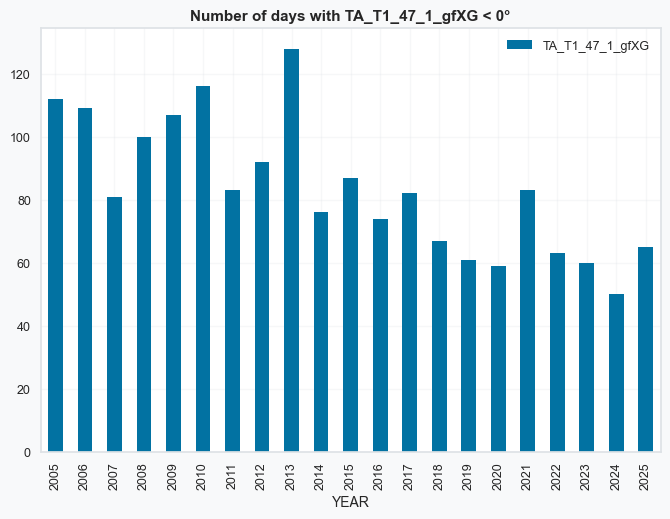

In [10]:
plotdf = df[[varname]].copy()
plotdf = plotdf.resample('D').min()
belowzero = plotdf.loc[plotdf[varname] < 0].copy()
belowzero = belowzero.groupby(belowzero.index.year).count()
belowzero["YEAR"] = belowzero.index
belowzero
belowzero.plot.bar(x="YEAR", y=varname, title=f"Number of days with {varname} < 0°");
display(belowzero)
print(f"Average per year: {belowzero[varname].mean()} +/- {belowzero[varname].std():.2f} SD")

## Number of days above 30°C

,TA_T1_47_1_gfXG,YEAR
TIMESTAMP_MIDDLE,,
2005,1,2005
2006,2,2006
2010,2,2010
2011,1,2011
2012,1,2012
2013,3,2013
2014,1,2014
2015,8,2015
2016,5,2016


Average per year: 4.705882352941177 +/- 3.27 SD


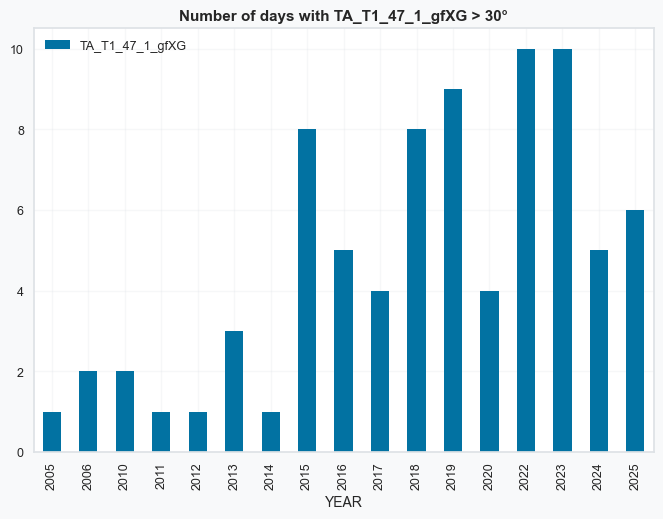

In [11]:
plotdf = df[[varname]].copy()
plotdf = plotdf.resample('D').max()
above = plotdf.loc[plotdf[varname] > 30].copy()
above = above.groupby(above.index.year).count()
above["YEAR"] = above.index
above.plot.bar(x="YEAR", y=varname, title=f"Number of days with {varname} > 30°");
display(above)
print(f"Average per year: {above[varname].mean()} +/- {above[varname].std():.2f} SD")

</br>

# Heatmap plots

## Half-hourly

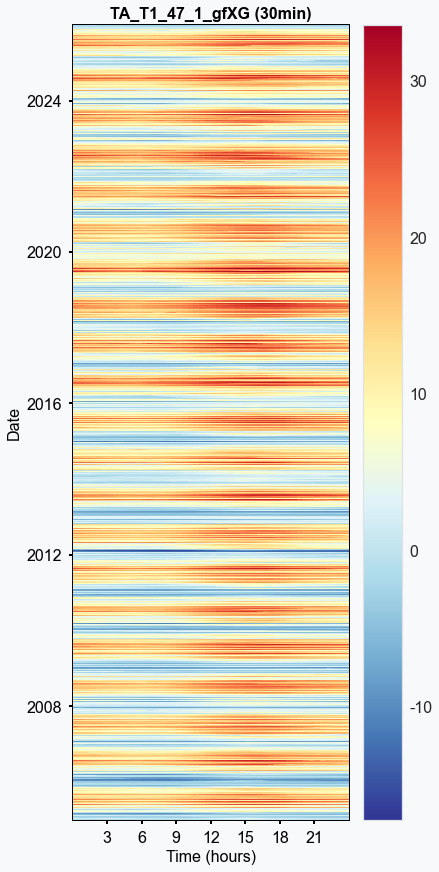

In [12]:
fig, axs = plt.subplots(ncols=1, figsize=(6, 12), dpi=72, layout="constrained")
dv.plotting.HeatmapDateTime(series=series).plot(ax=axs, cb_digits_after_comma=0)

## Monthly

In [13]:
series.resample('ME').mean()

TIMESTAMP_MIDDLE
2005-01-31    -1.805817
2005-02-28    -3.298523
2005-03-31     3.614032
2005-04-30     7.327111
2005-05-31    11.914358
                ...    
2025-08-31    19.276117
2025-09-30    14.114801
2025-10-31     8.860731
2025-11-30     4.860499
2025-12-31     1.703691
Freq: ME, Name: TA_T1_47_1_gfXG, Length: 252, dtype: float64

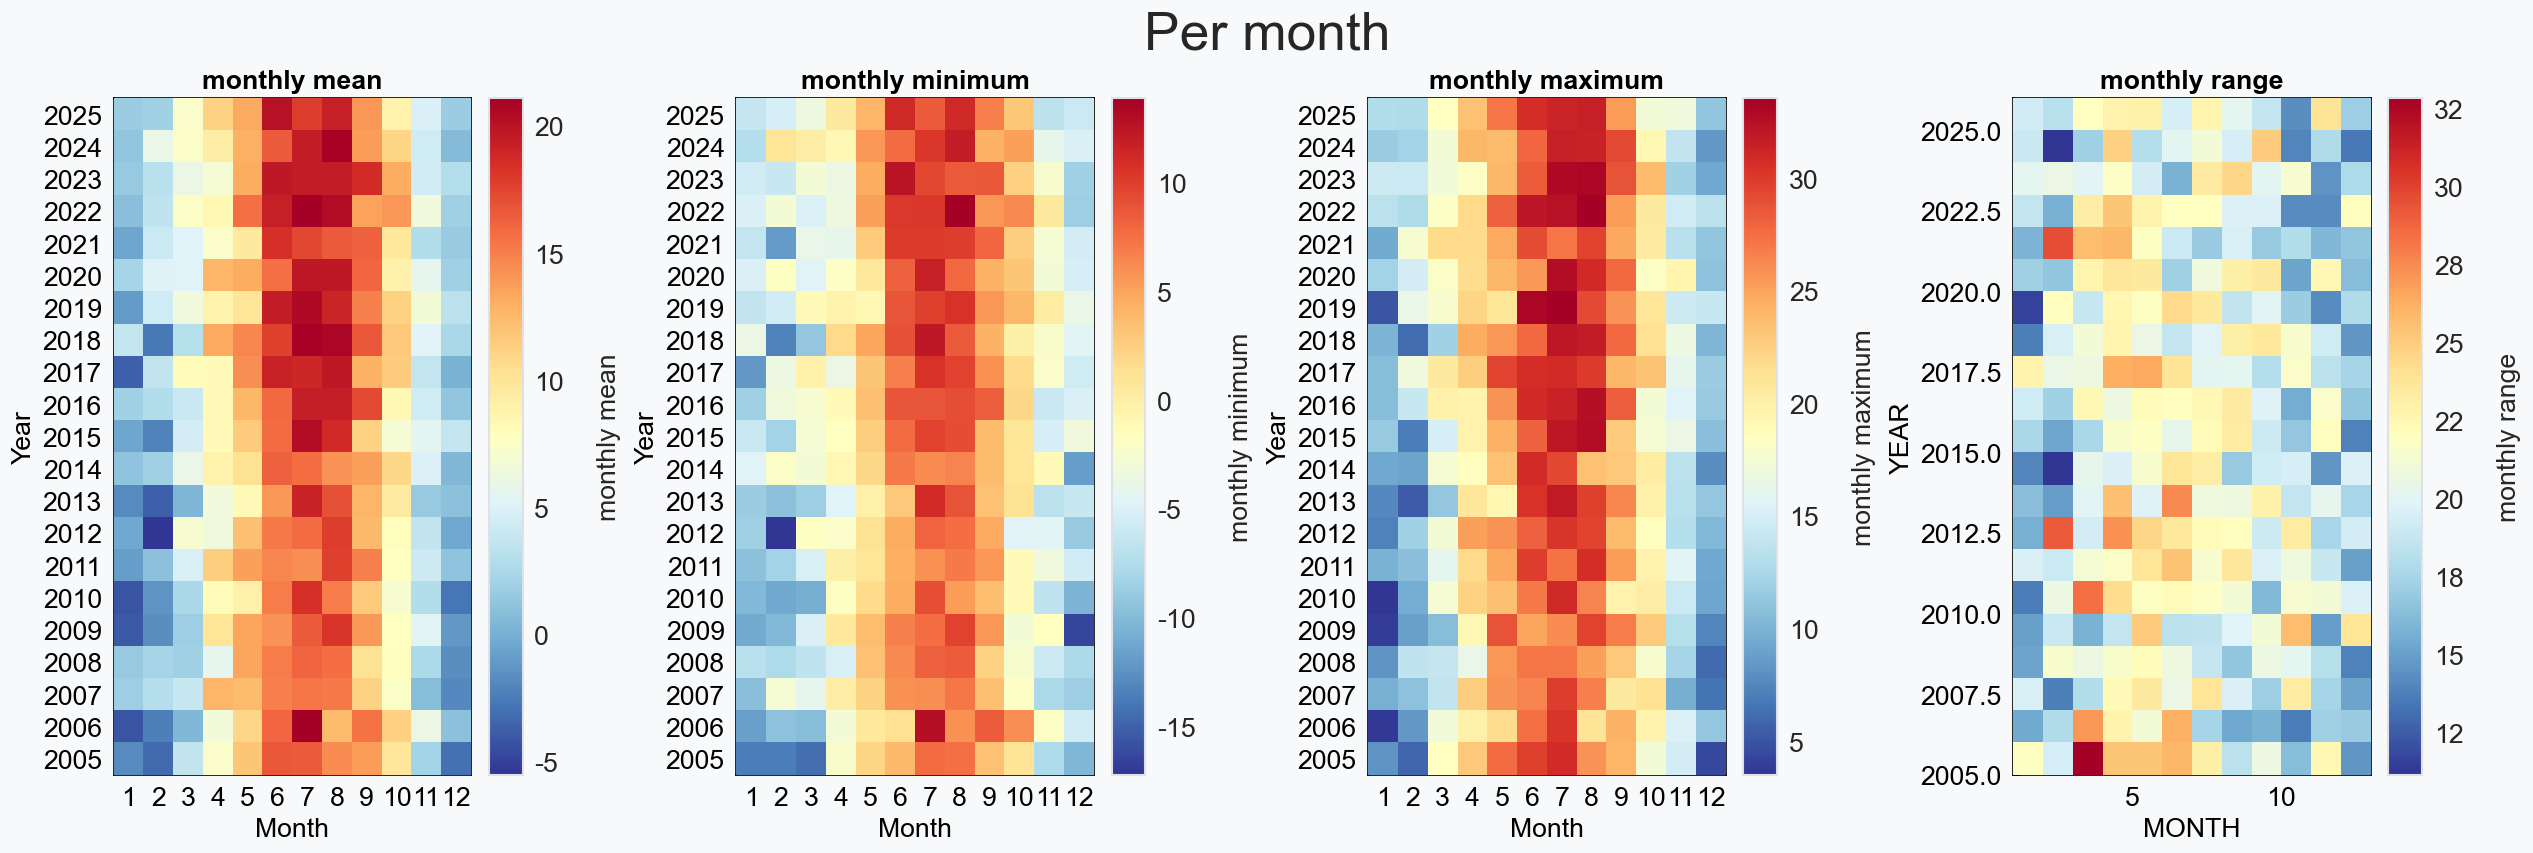

In [14]:
fig, axs = plt.subplots(ncols=4, figsize=(21, 7), dpi=120, layout="constrained")
fig.suptitle(f'Per month', fontsize=32)

# HeatmapYearMonth aggregates the half-hourly series itself, so it is passed unresampled.
for _ax, _agg, _label in [(axs[0], 'mean', "monthly mean"),
                          (axs[1], 'min', "monthly minimum"),
                          (axs[2], 'max', "monthly maximum")]:
    dv.plotting.HeatmapYearMonth(series=series, agg=_agg).plot(
        ax=_ax, cb_digits_after_comma=0, zlabel=_label,
        format_style=dv.plotting.FormatStyle(title=_label))

# There is no 'range' aggregation, so the range is computed from the max and min year-month
# matrices and drawn on the same grid with HeatmapXYZ.
_range = (dv.plotting.HeatmapYearMonth(series=series, agg='max').get_plot_data()
          - dv.plotting.HeatmapYearMonth(series=series, agg='min').get_plot_data())
_range_lf = _range.stack().rename("monthly range").reset_index()
dv.plotting.HeatmapXYZ(x=_range_lf['MONTH'], y=_range_lf['YEAR'], z=_range_lf["monthly range"]).plot(
    ax=axs[3], cb_digits_after_comma=0, zlabel="monthly range",
    format_style=dv.plotting.FormatStyle(title="monthly range"))

## Monthly ranks

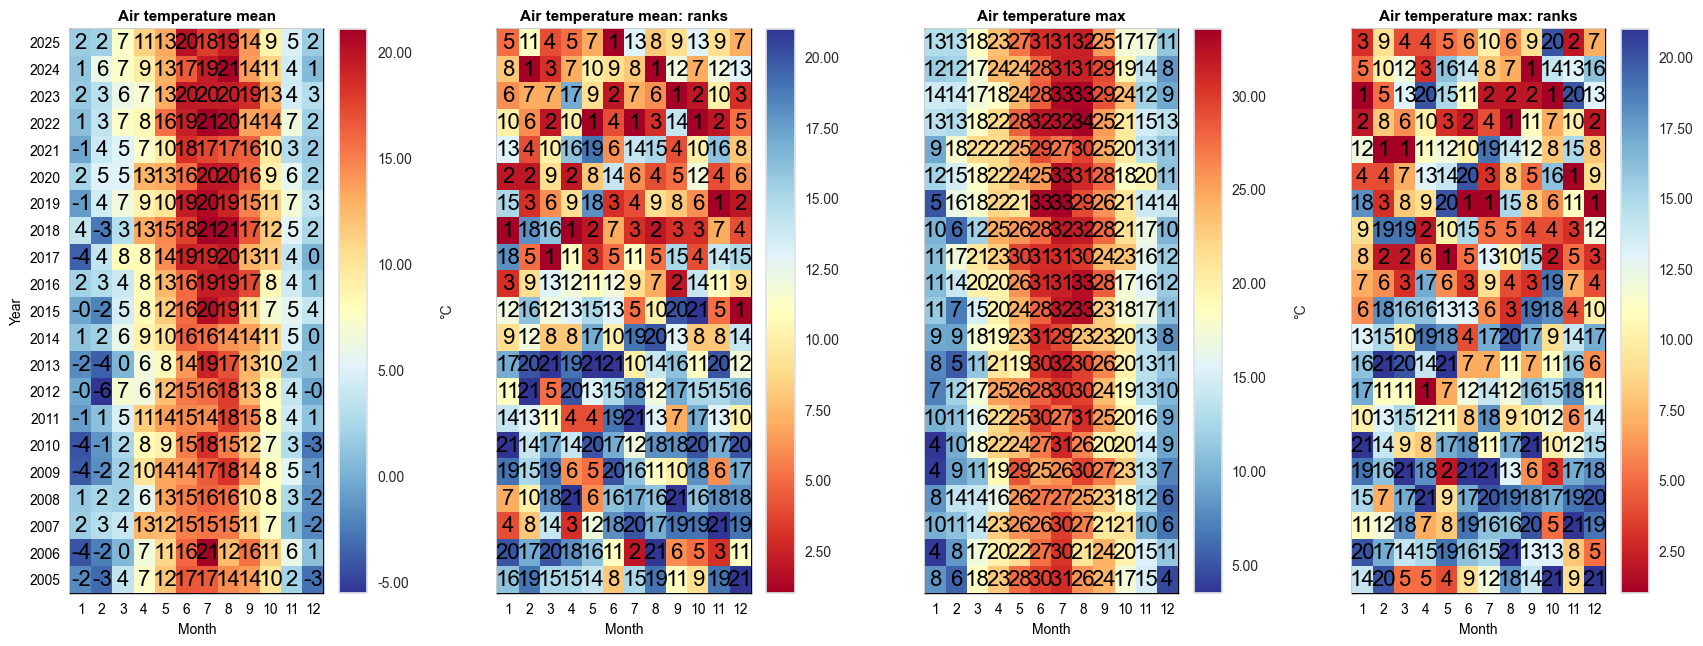

In [15]:
# Figure
fig = plt.figure(facecolor='white', figsize=(17, 6))

# Gridspec for layout
gs = gridspec.GridSpec(1, 4)  # rows, cols
gs.update(wspace=0.35, hspace=0.3, left=0.03, right=0.97, top=0.97, bottom=0.03)
ax_mean = fig.add_subplot(gs[0, 0])
ax_mean_ranks = fig.add_subplot(gs[0, 1])
ax_max = fig.add_subplot(gs[0, 2])
ax_max_ranks = fig.add_subplot(gs[0, 3])
style = dv.plotting.FormatStyle(axlabel_fontsize=10, ticks_fontsize=10)
params = {'show_values': True, 'cb_labelsize': 10, 'format_style': style}

dv.plotting.HeatmapYearMonth(series=series, agg='mean', ranks=False).plot(
    ax=ax_mean, zlabel="°C", cmap="RdYlBu_r", **params)

# Kept as a name: the ranks matrix is read back out of it further down.
hm_mean_ranks = dv.plotting.HeatmapYearMonth(series=series, agg='mean', ranks=True)
hm_mean_ranks.plot(ax=ax_mean_ranks, **params)

dv.plotting.HeatmapYearMonth(series=series, agg='max', ranks=False).plot(
    ax=ax_max, zlabel="°C", cmap="RdYlBu_r", **params)
dv.plotting.HeatmapYearMonth(series=series, agg='max', ranks=True).plot(
    ax=ax_max_ranks, **params)

ax_mean.set_title("Air temperature mean", color='black')
ax_mean_ranks.set_title("Air temperature mean: ranks", color='black')
ax_max.set_title("Air temperature max", color='black')
ax_max_ranks.set_title("Air temperature max: ranks", color='black')

ax_mean.tick_params(left=True, right=False, top=False, bottom=True,
                    labelleft=True, labelright=False, labeltop=False, labelbottom=True)
ax_mean_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                   labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)

ax_mean_ranks.set_ylabel("")
ax_max.set_ylabel("")
ax_max_ranks.set_ylabel("")

fig.show()

### Mean ranks per year

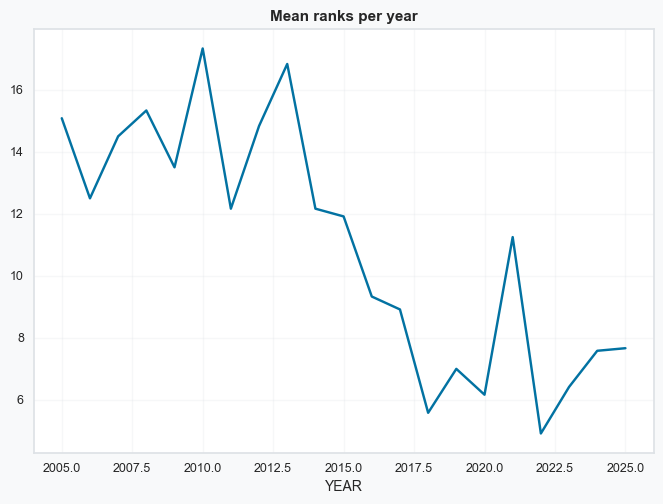

In [16]:
hm_mean_ranks.get_plot_data().mean(axis=1).plot(title="Mean ranks per year");

</br>

# Ridgeline plots

## Yearly

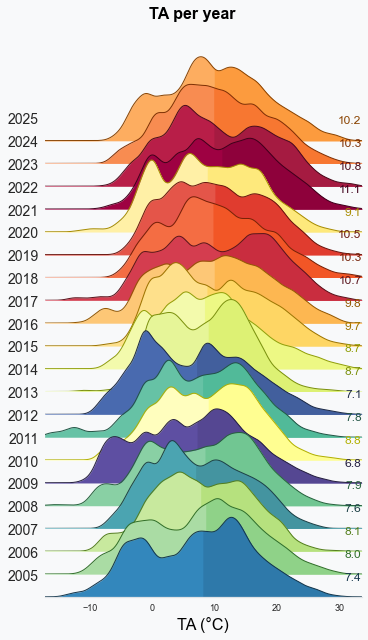

In [17]:
rp = dv.plotting.RidgeLinePlot(series=series)
rp.plot(
    how='yearly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.07],  # min/max as list
    hspace=-0.8,  # overlap between months
    fig_width=5,
    fig_height=9,
    shade_percentile=0.5,
    show_mean_line=False,
    format_style=dv.plotting.FormatStyle(xlabel=xlabel, title=f"{var} per year"),
    fig_dpi=72,
    showplot=True,
    ascending=False
)

## Monthly

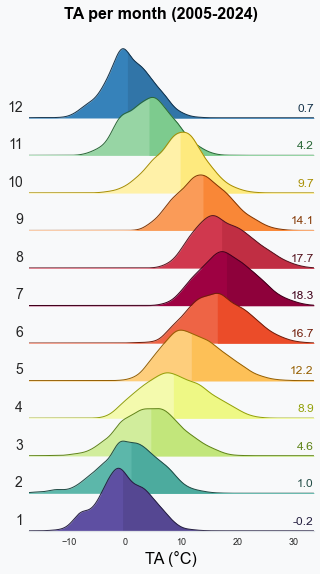

In [18]:
rp.plot(
    how='monthly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.14],  # min/max as list
    hspace=-0.6,  # overlap between months
    fig_width=4.5,
    fig_height=8,
    shade_percentile=0.5,
    show_mean_line=False,
    format_style=dv.plotting.FormatStyle(xlabel=xlabel, title=f"{var} per month (2005-2024)"),
    fig_dpi=72,
    showplot=True,
    ascending=False
)

## Weekly

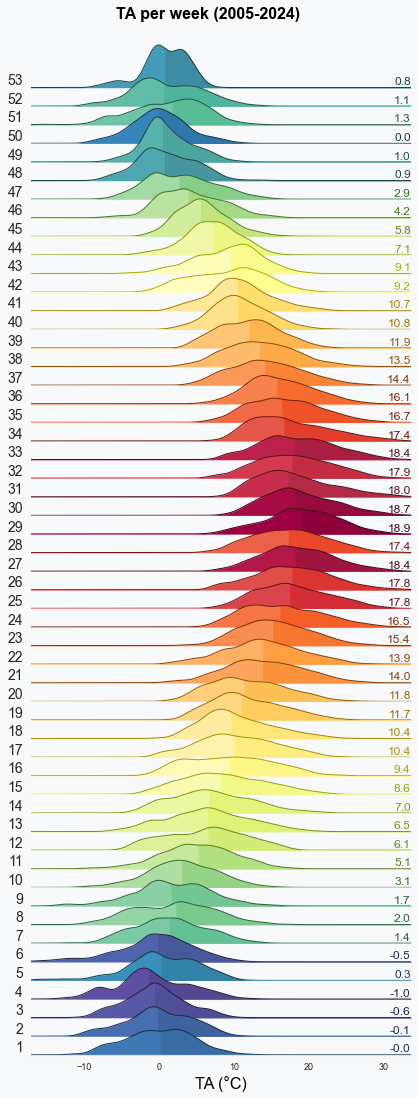

In [19]:
rp.plot(
    how='weekly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.15],  # min/max as list
    hspace=-0.6,  # overlap
    fig_width=6,
    fig_height=16,
    shade_percentile=0.5,
    show_mean_line=False,
    format_style=dv.plotting.FormatStyle(xlabel=xlabel, title=f"{var} per week (2005-2024)"),
    fig_dpi=72,
    showplot=True,
    ascending=False
)

## Single years per month

F:\dev\diive\diive\core\plotting\ridgeline.py:153: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig = plt.figure(figsize=(self.fig_width, self.fig_height),


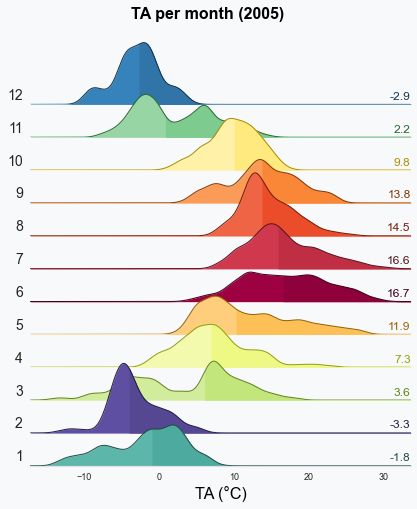

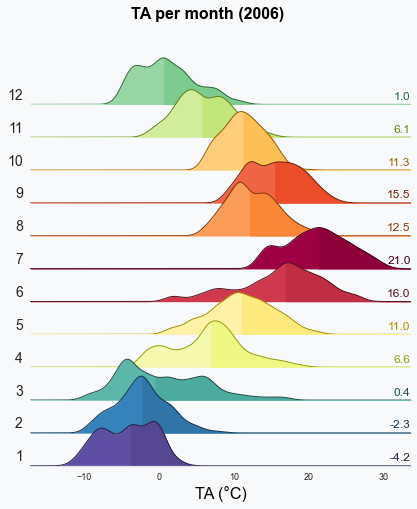

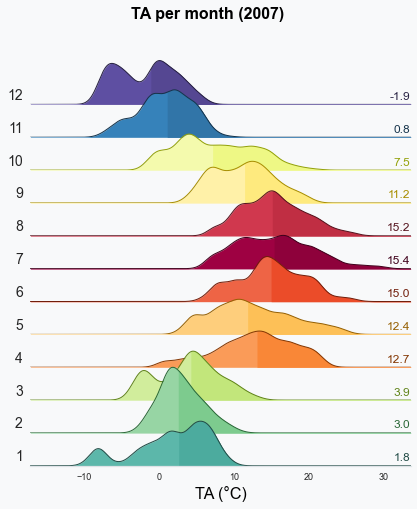

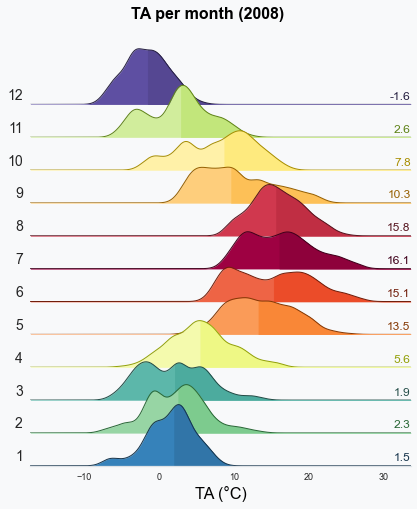

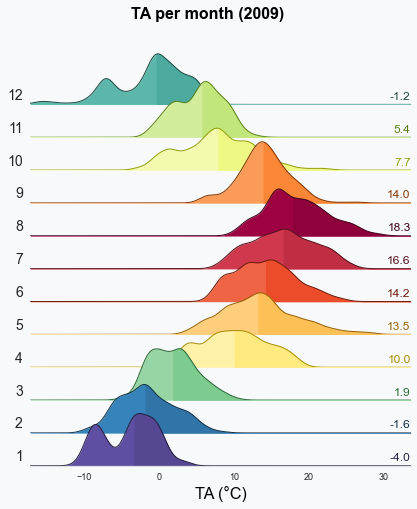

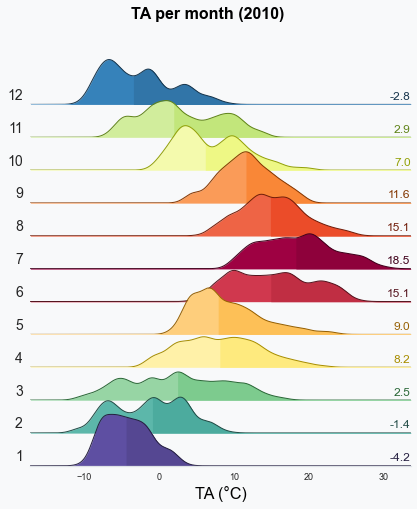

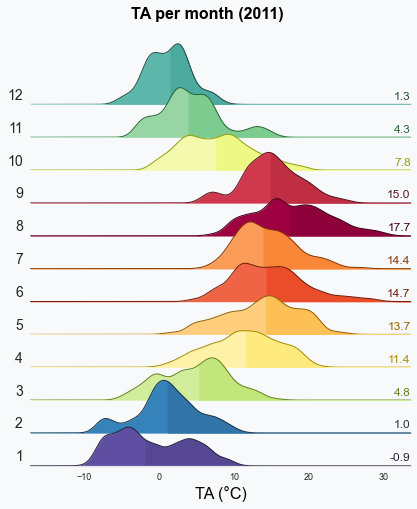

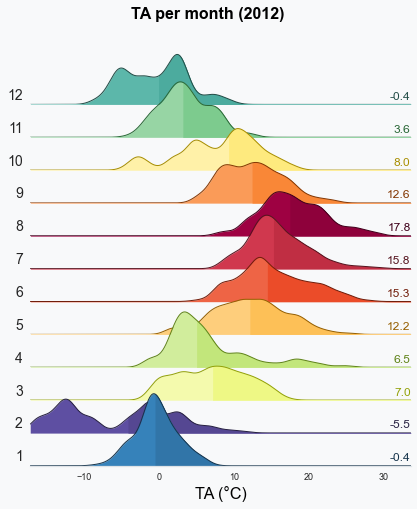

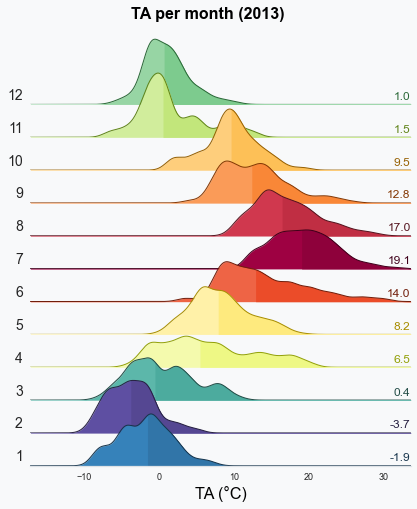

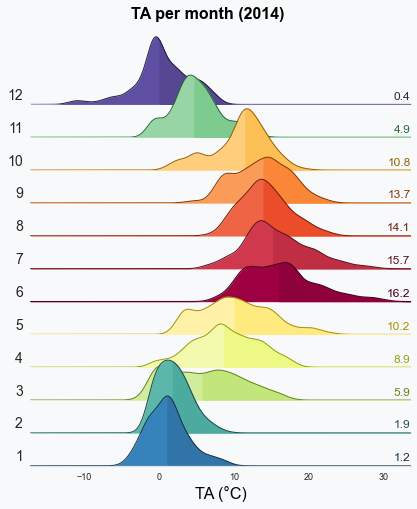

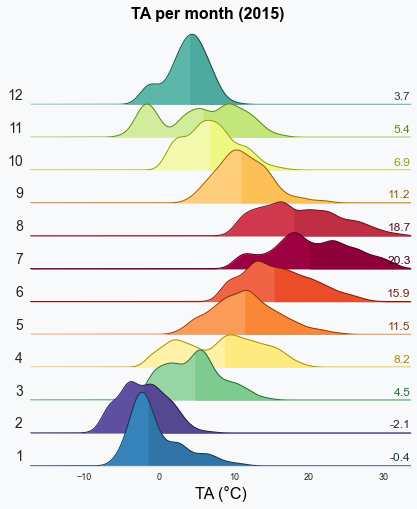

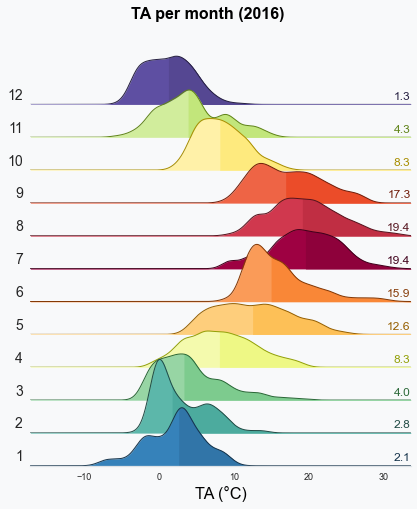

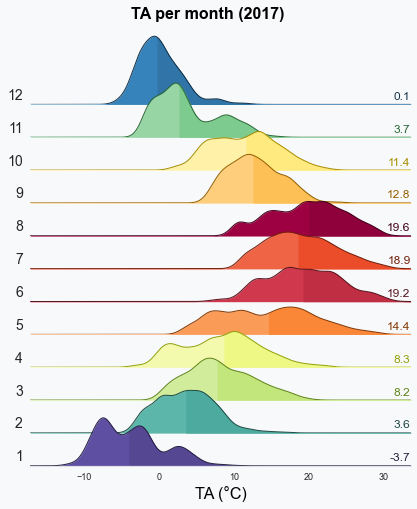

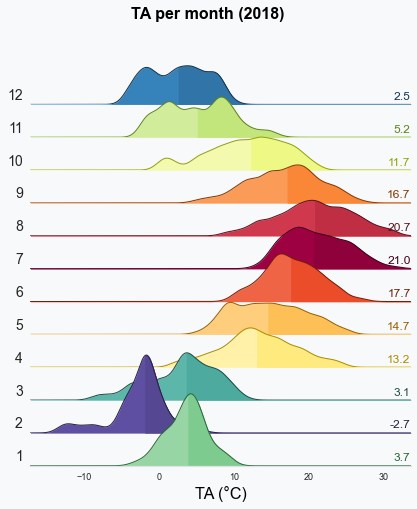

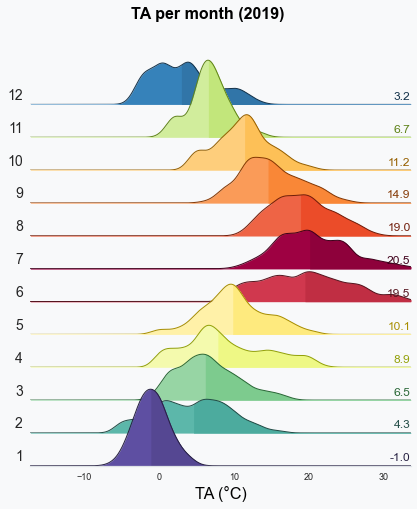

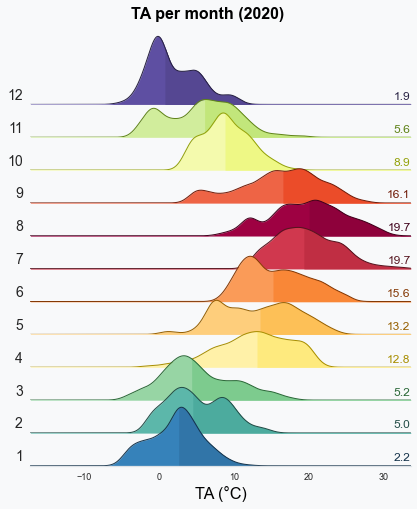

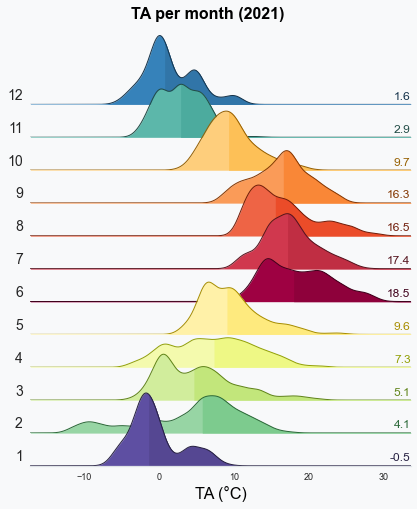

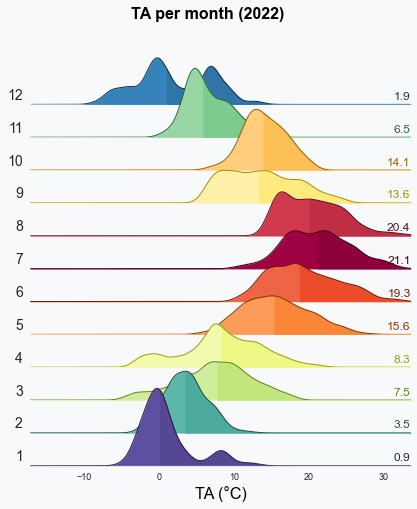

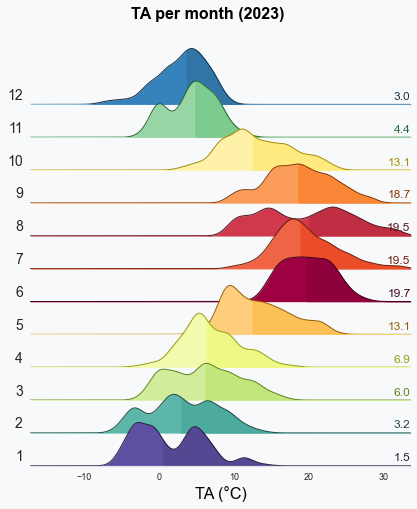

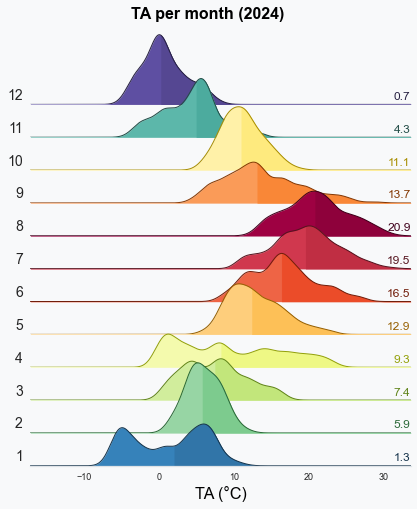

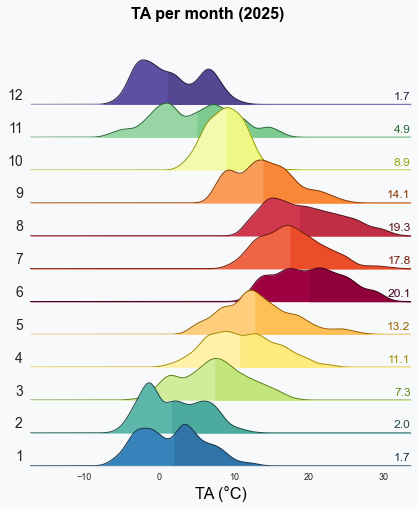

In [20]:
uniq_years = series.index.year.unique()
for uy in uniq_years:
    series_yr = series.loc[series.index.year == uy].copy()
    rp = dv.plotting.RidgeLinePlot(series=series_yr)
    rp.plot(
        how='monthly',
        kd_kwargs=None,  # params from scikit KernelDensity as dict
        xlim=xlim,  # min/max as list
        ylim=[0, 0.18],  # min/max as list
        hspace=-0.6,  # overlap
        fig_width=6,
        fig_height=7,
        shade_percentile=0.5,
        show_mean_line=False,
        format_style=dv.plotting.FormatStyle(xlabel=xlabel, title=f"{var} per month ({uy})"),
        fig_dpi=72,
        showplot=True,
        ascending=False
    )

## Single years per week

F:\dev\diive\diive\core\plotting\ridgeline.py:153: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig = plt.figure(figsize=(self.fig_width, self.fig_height),


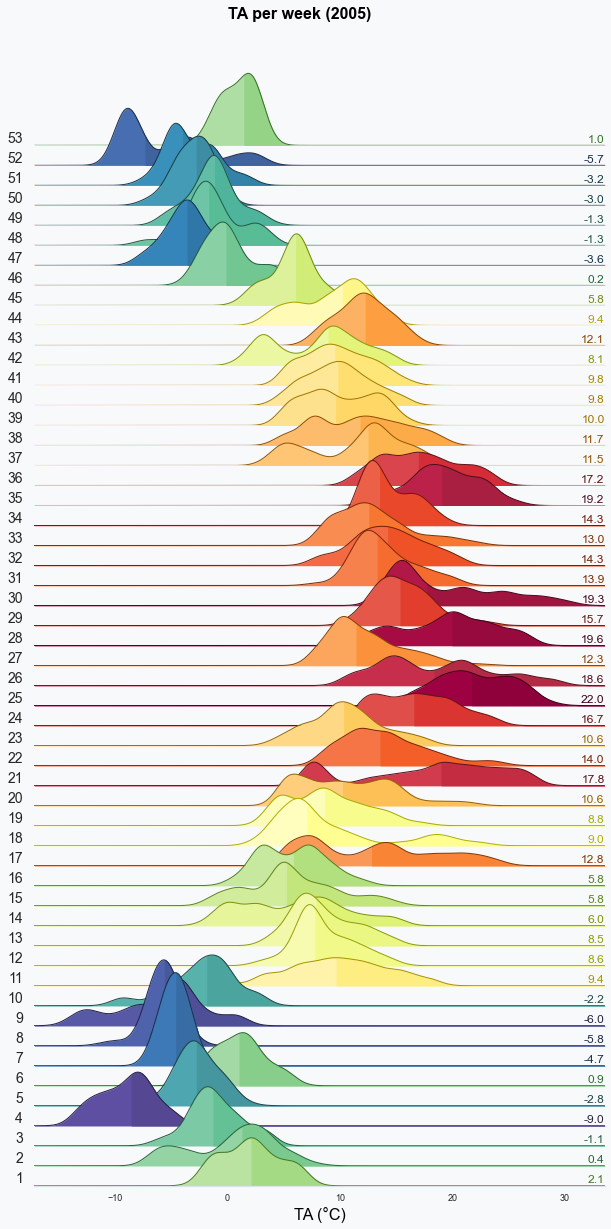

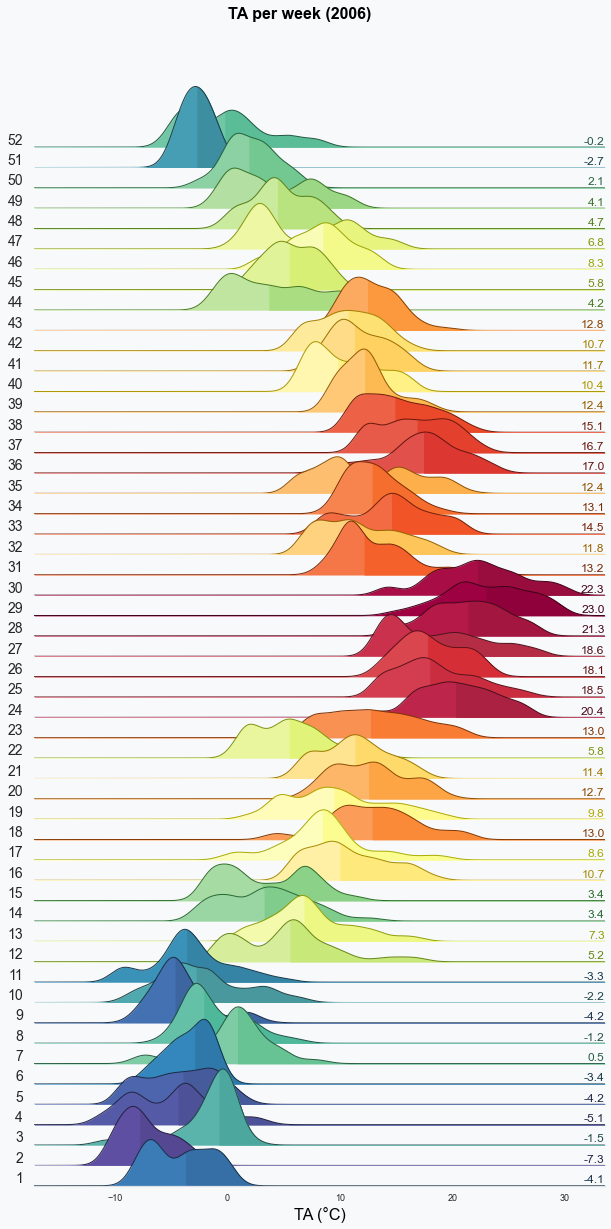

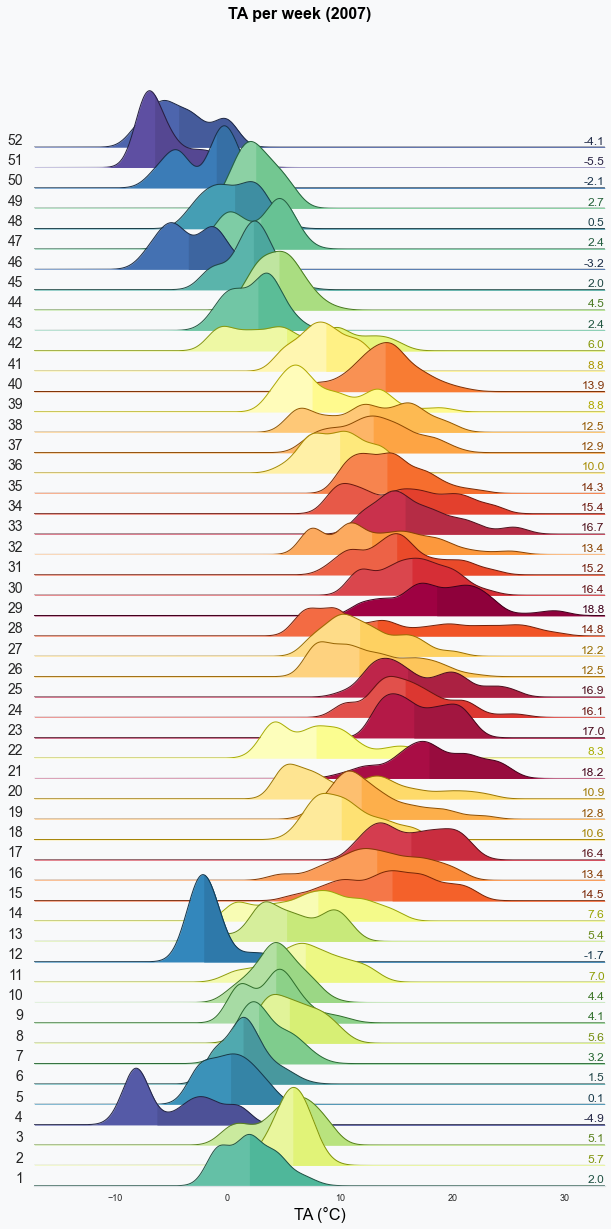

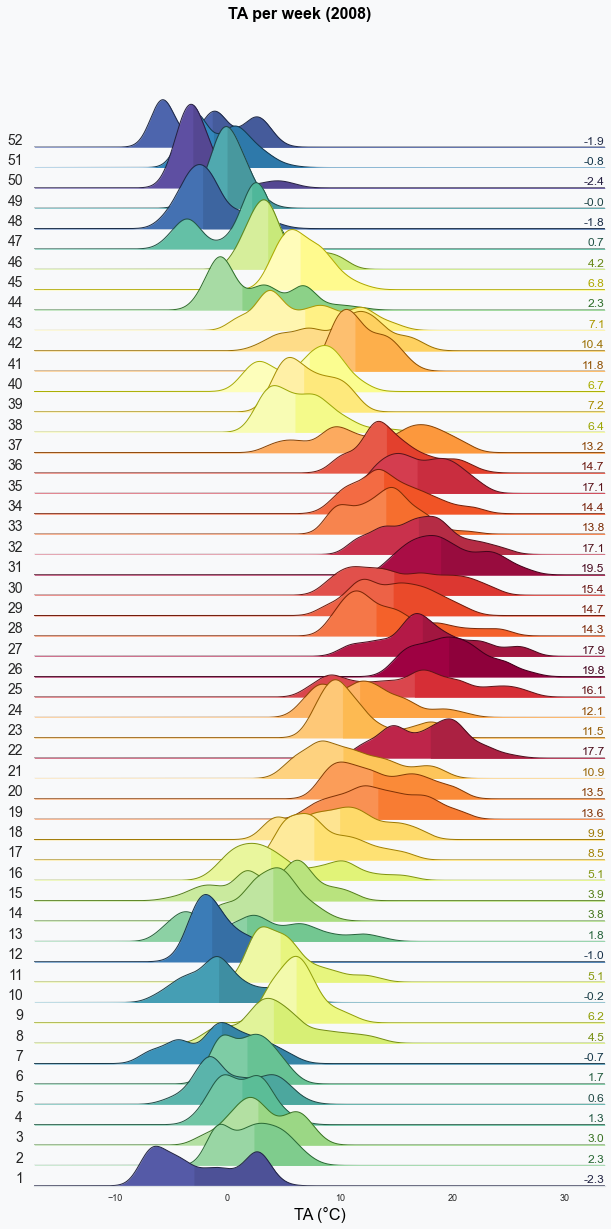

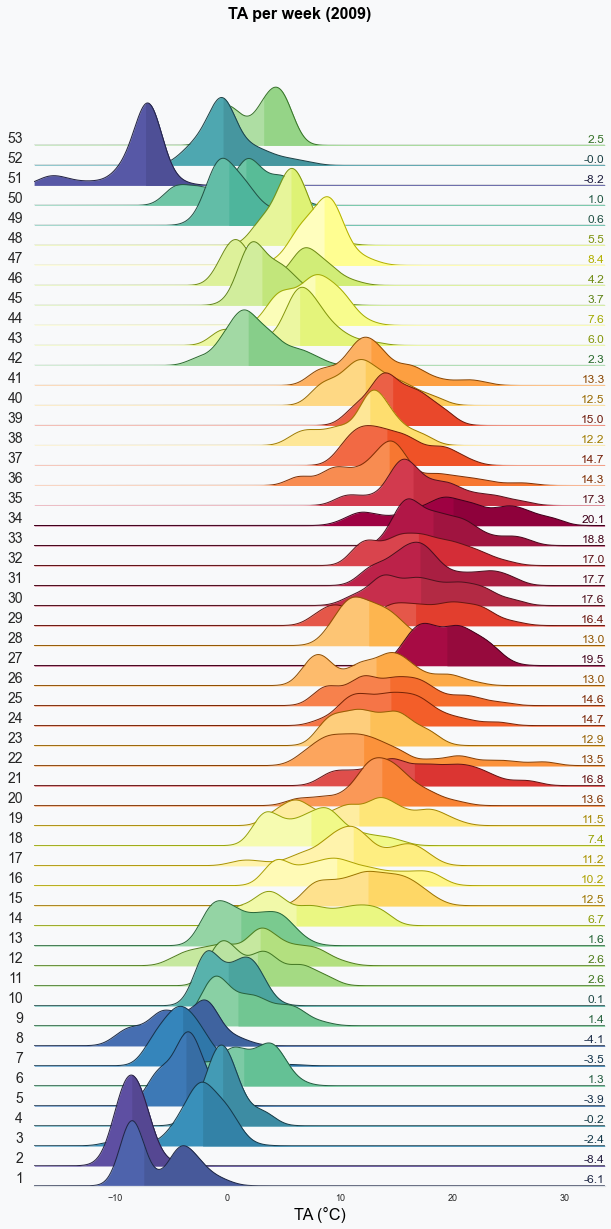

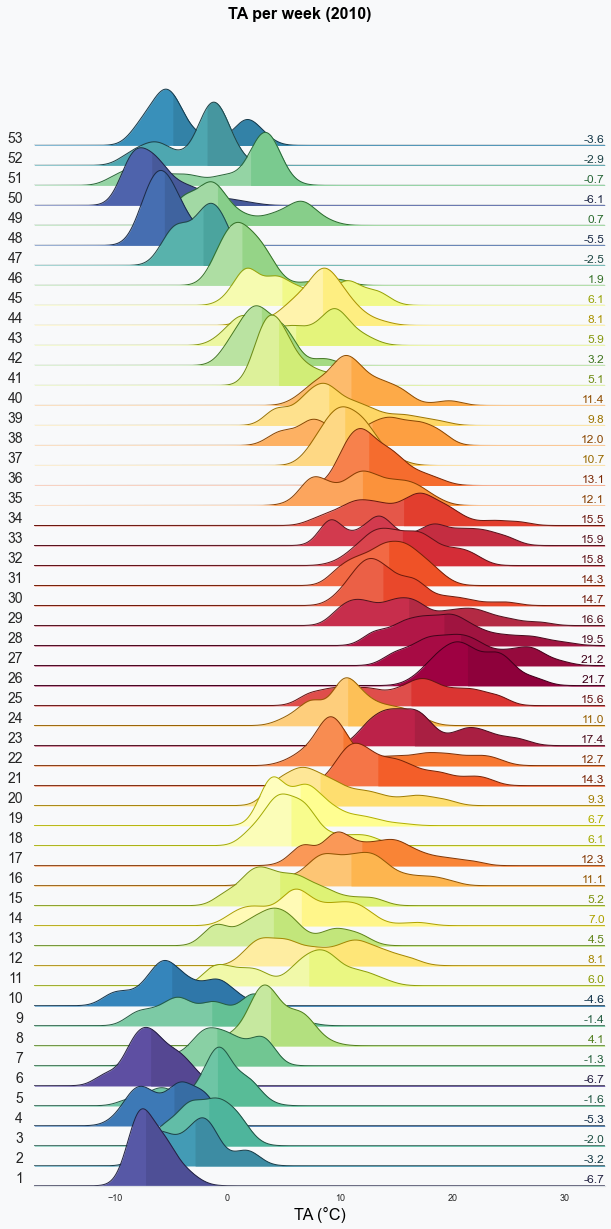

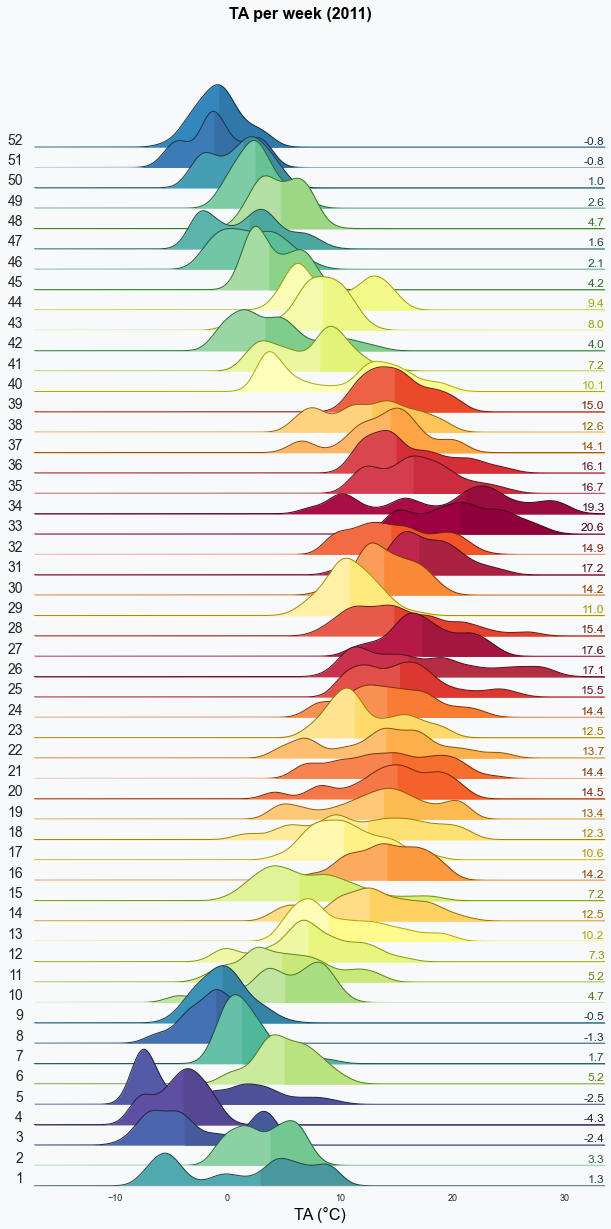

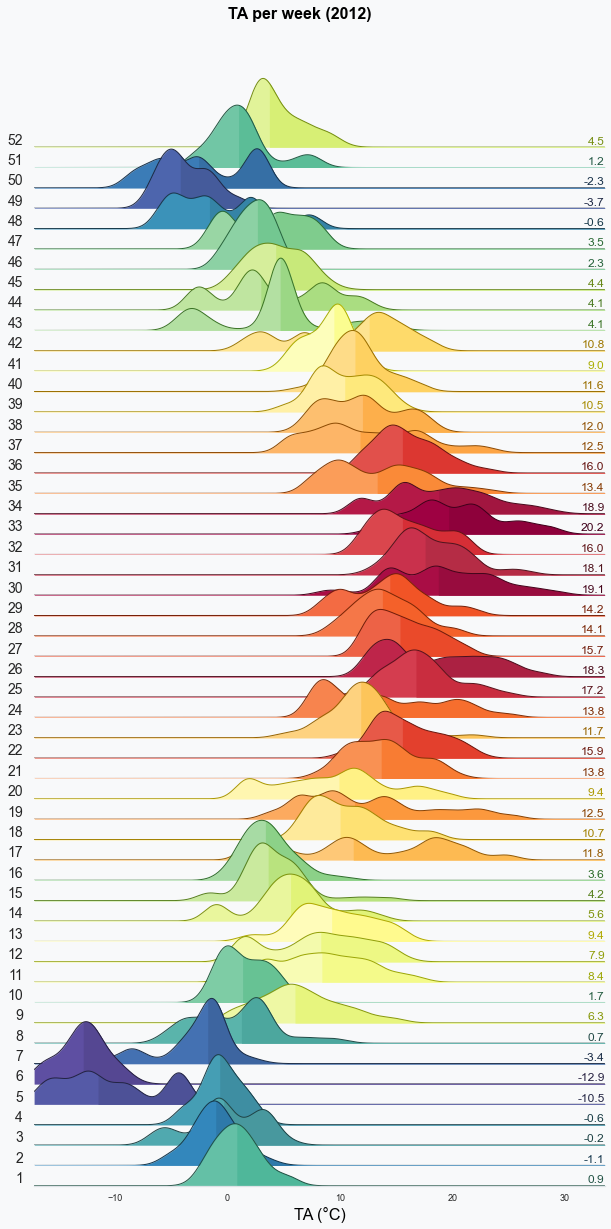

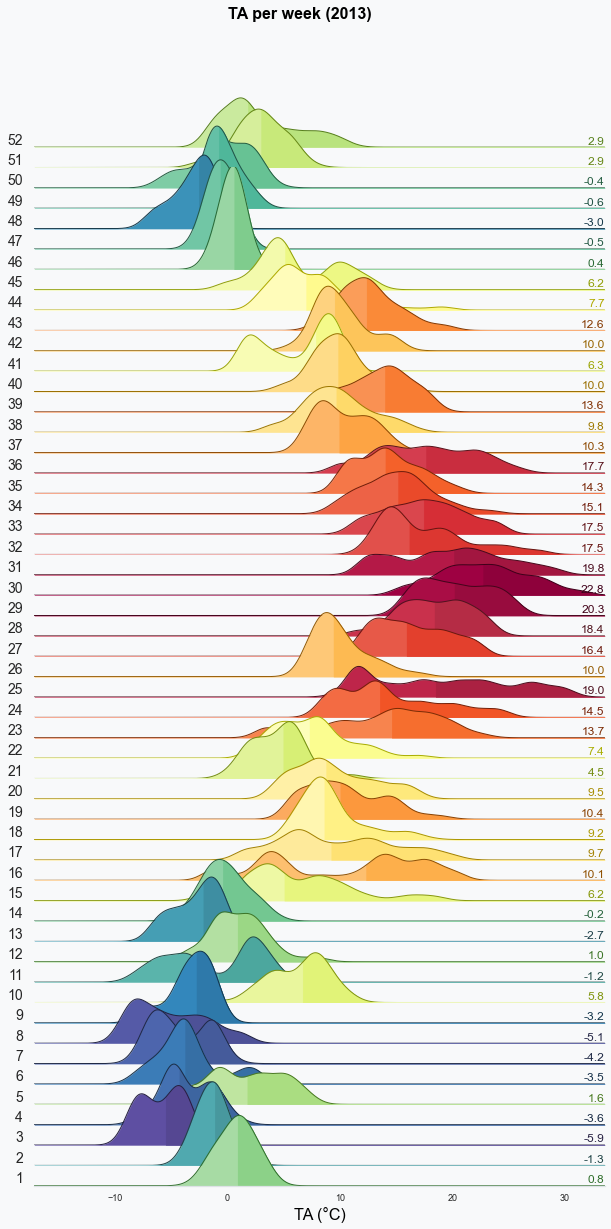

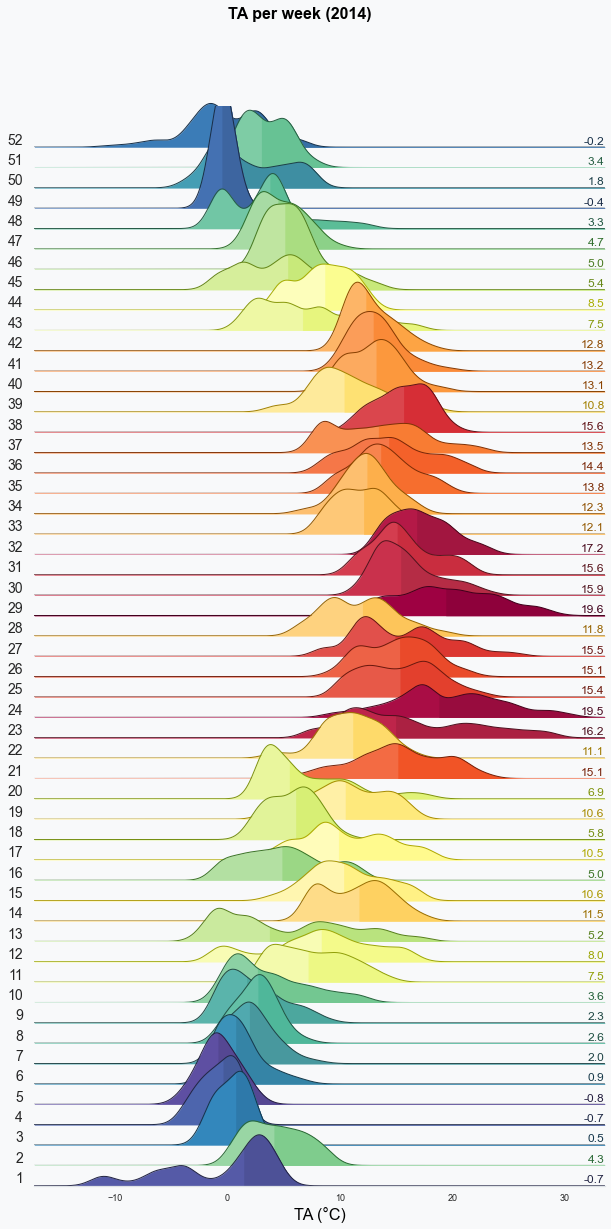

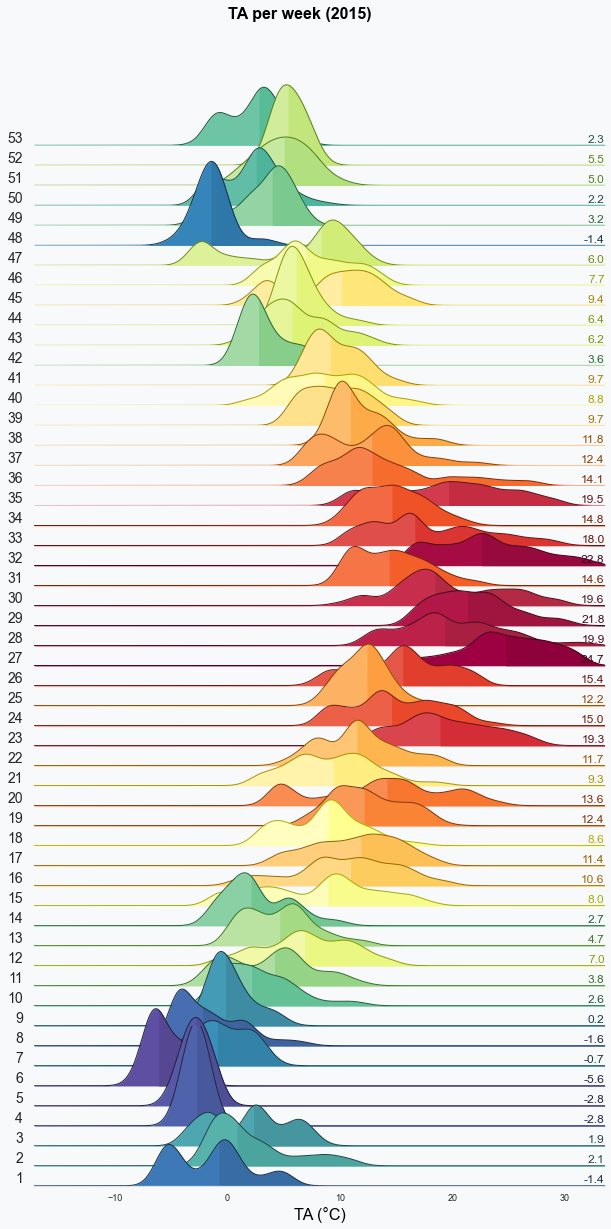

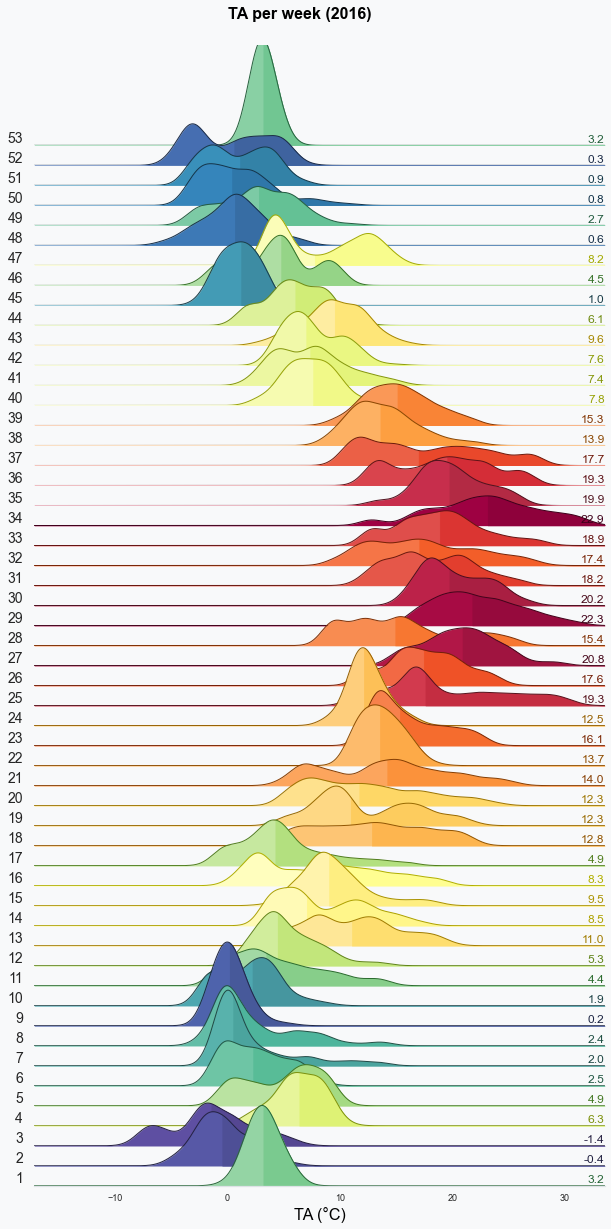

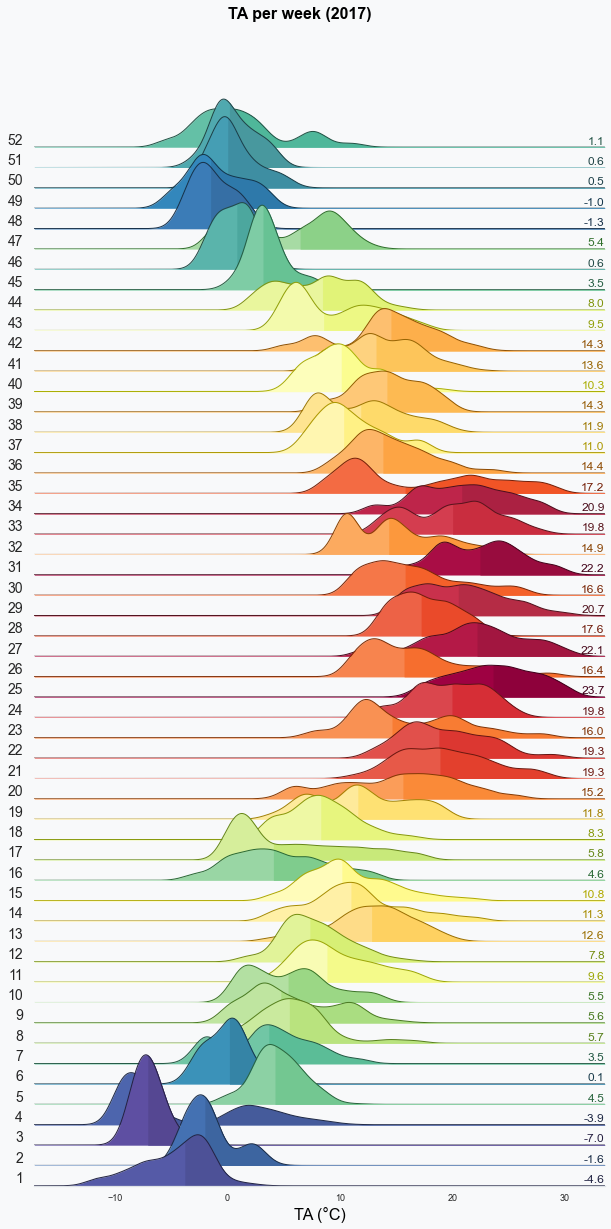

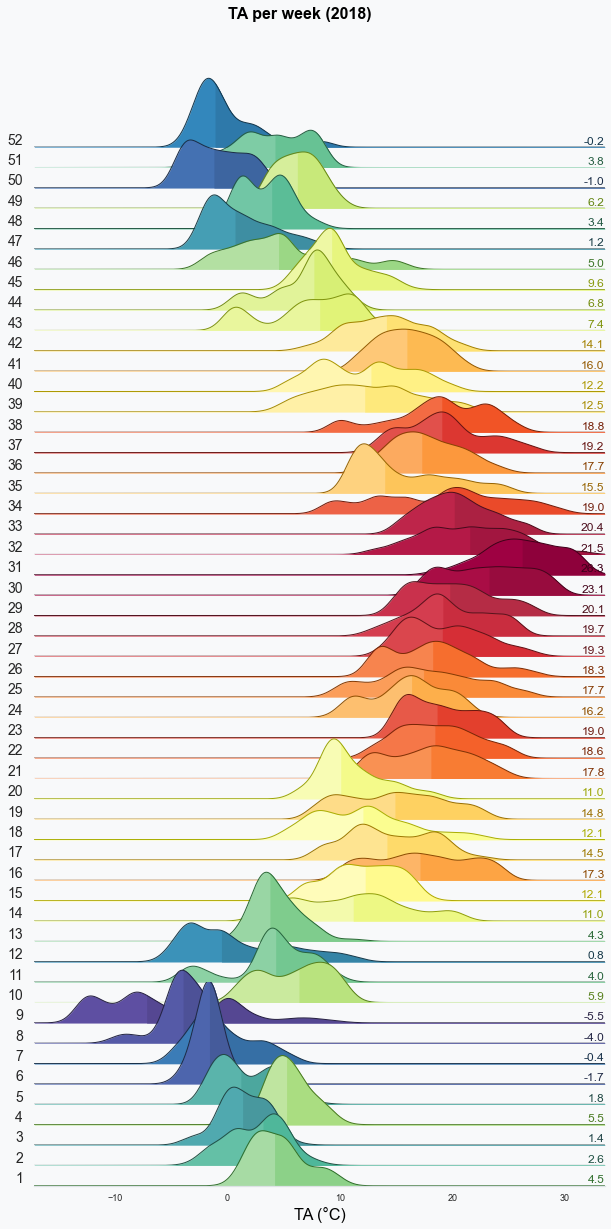

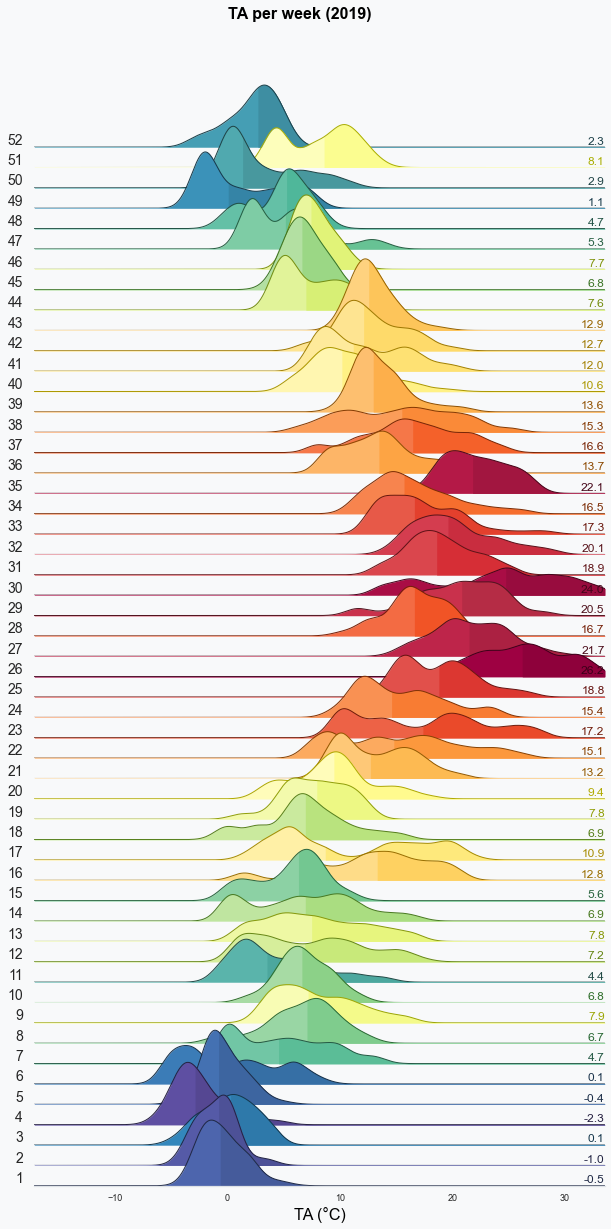

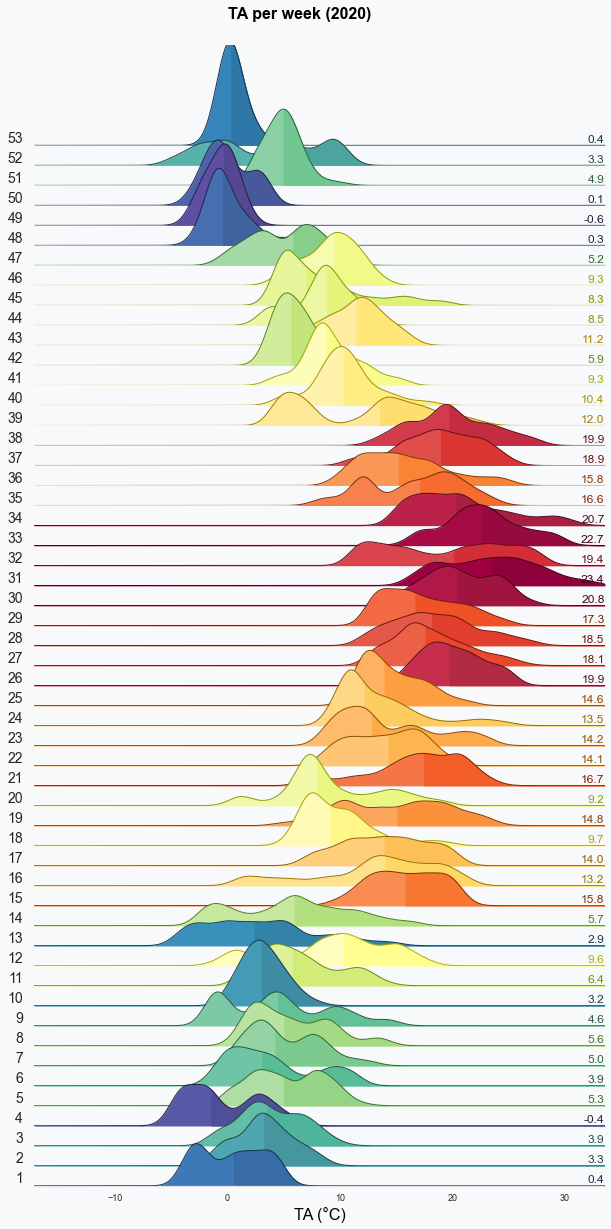

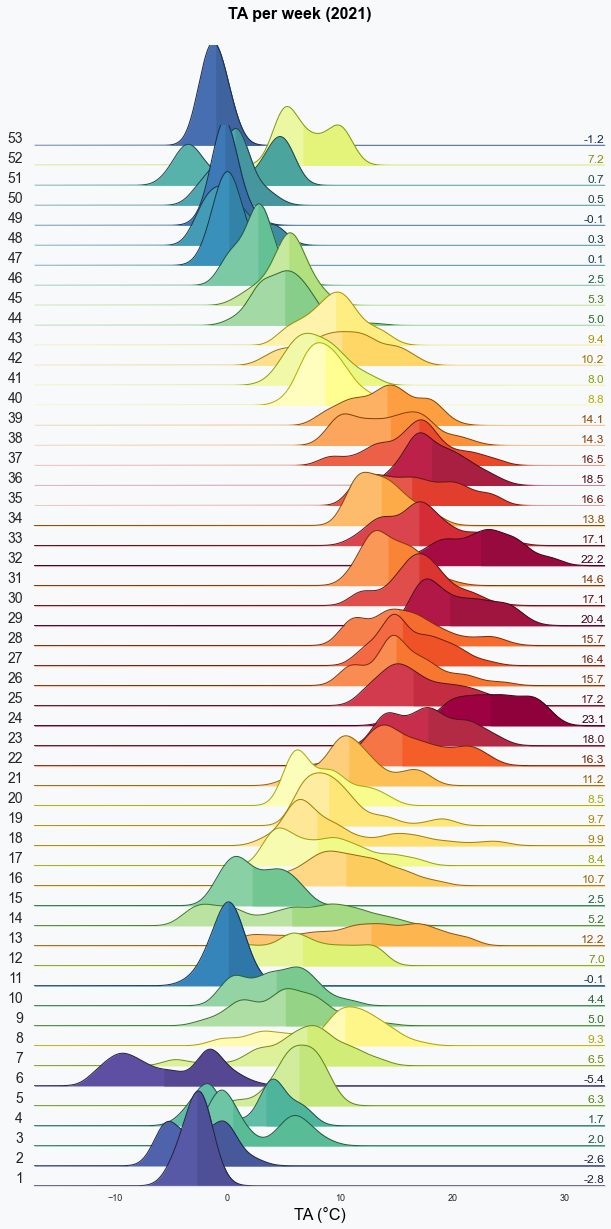

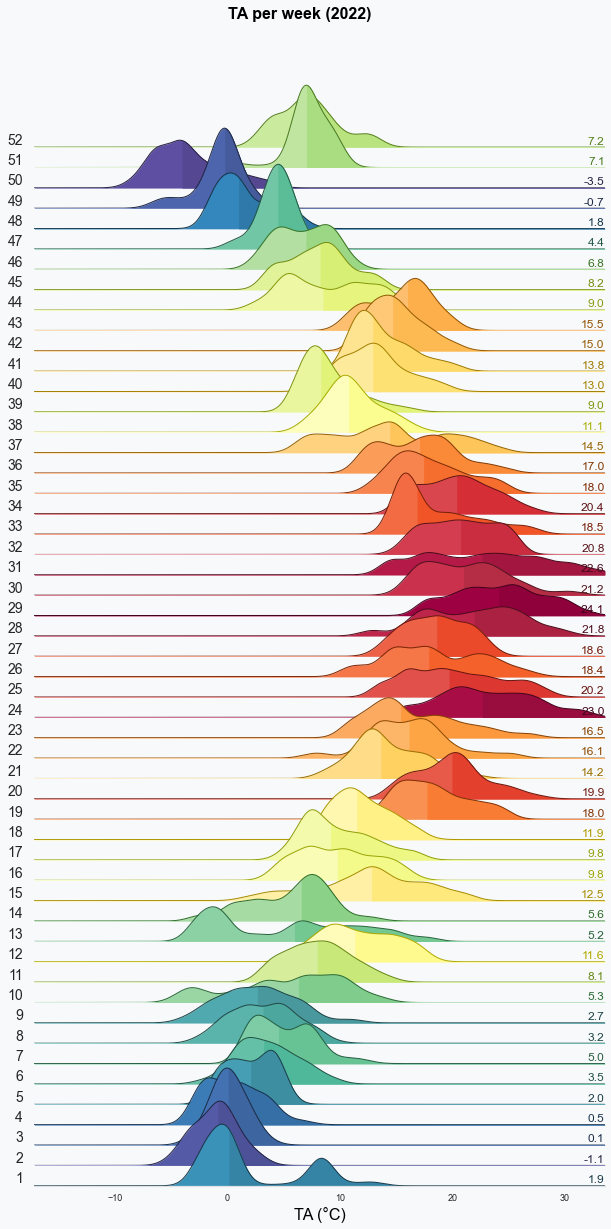

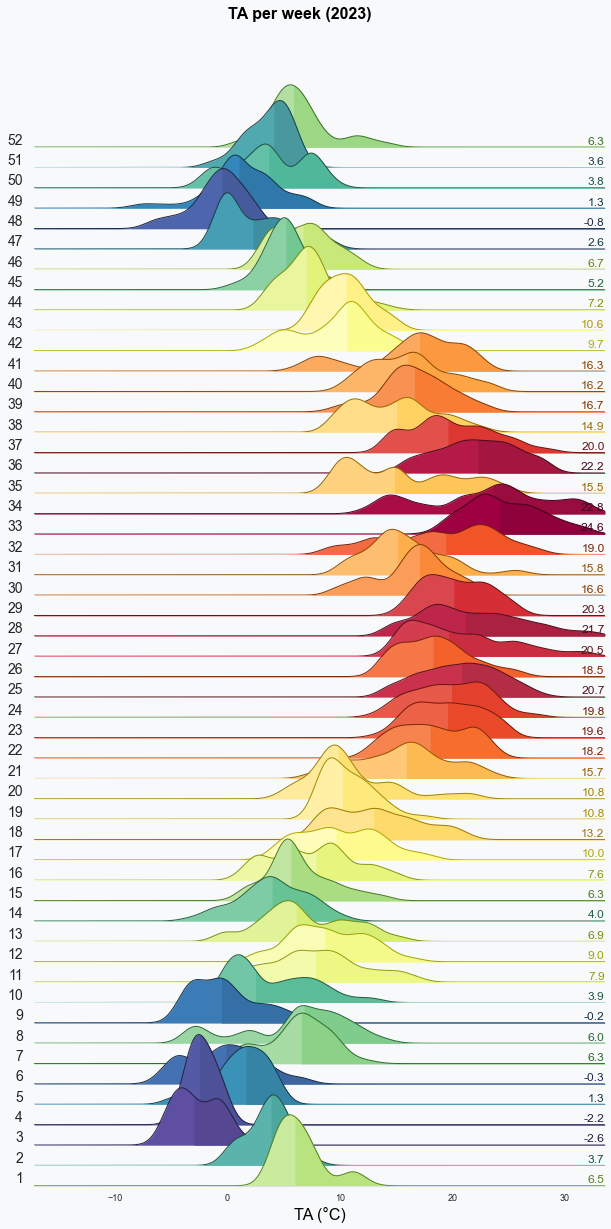

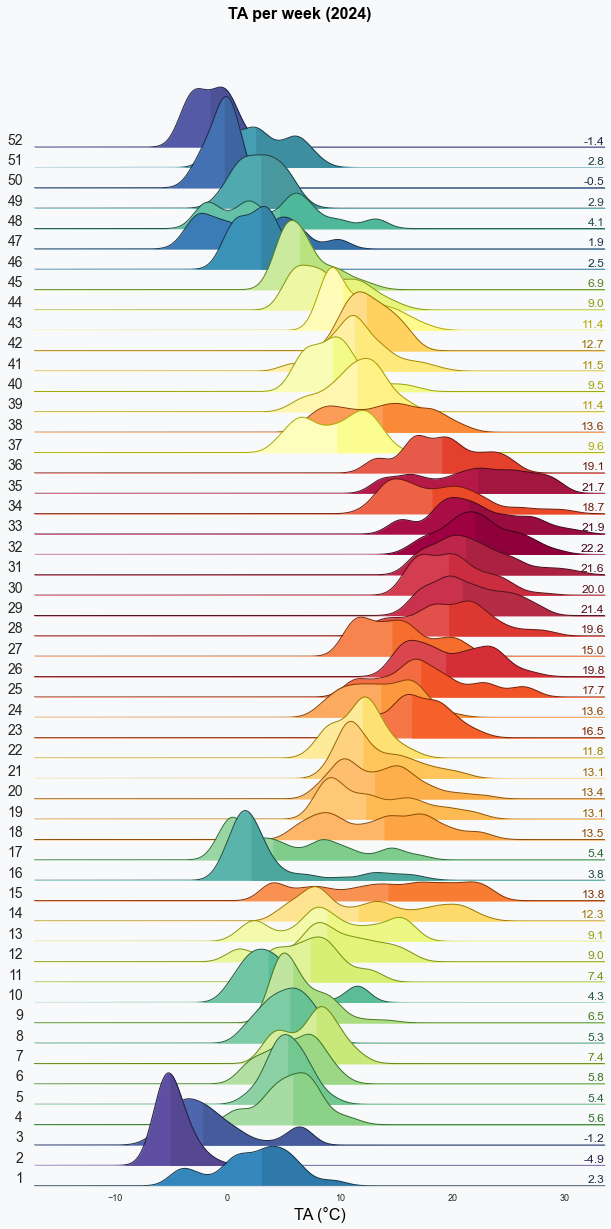

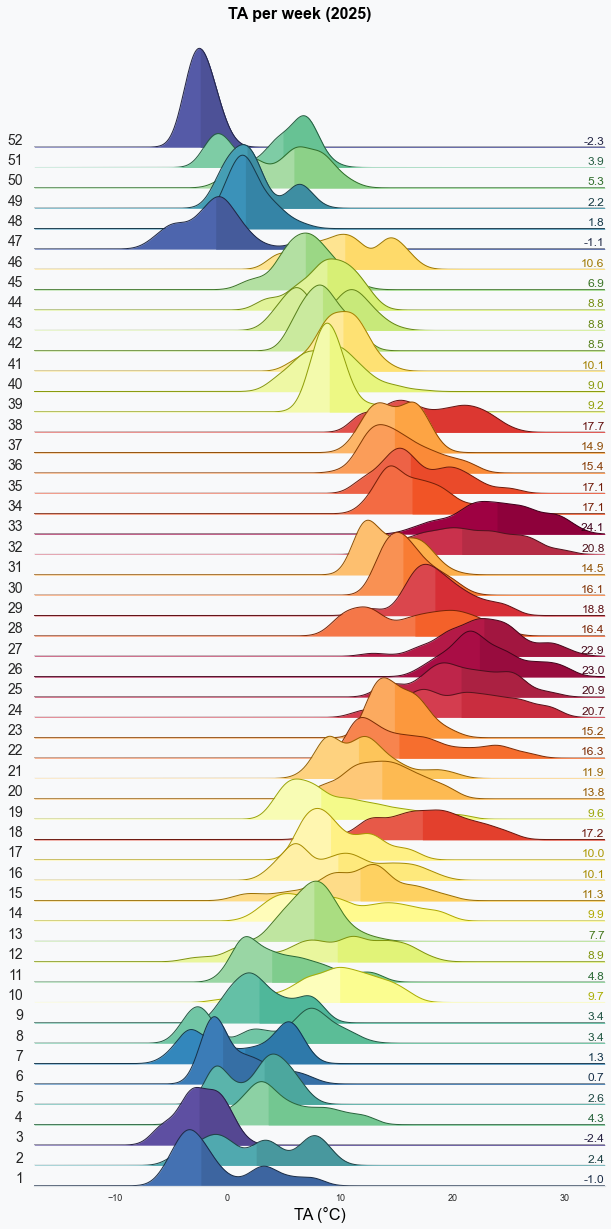

In [21]:
uniq_years = series.index.year.unique()
for uy in uniq_years:
    series_yr = series.loc[series.index.year == uy].copy()
    rp = dv.plotting.RidgeLinePlot(series=series_yr)
    rp.plot(
        how='weekly',
        kd_kwargs=None,  # params from scikit KernelDensity as dict
        xlim=xlim,  # min/max as list
        ylim=[0, 0.3],  # min/max as list
        hspace=-0.8,  # overlap
        fig_width=9,
        fig_height=18,
        shade_percentile=0.5,
        show_mean_line=False,
        format_style=dv.plotting.FormatStyle(xlabel=xlabel, title=f"{var} per week ({uy})"),
        fig_dpi=72,
        showplot=True,
        ascending=False
    )

</br>

# Cumulative plot

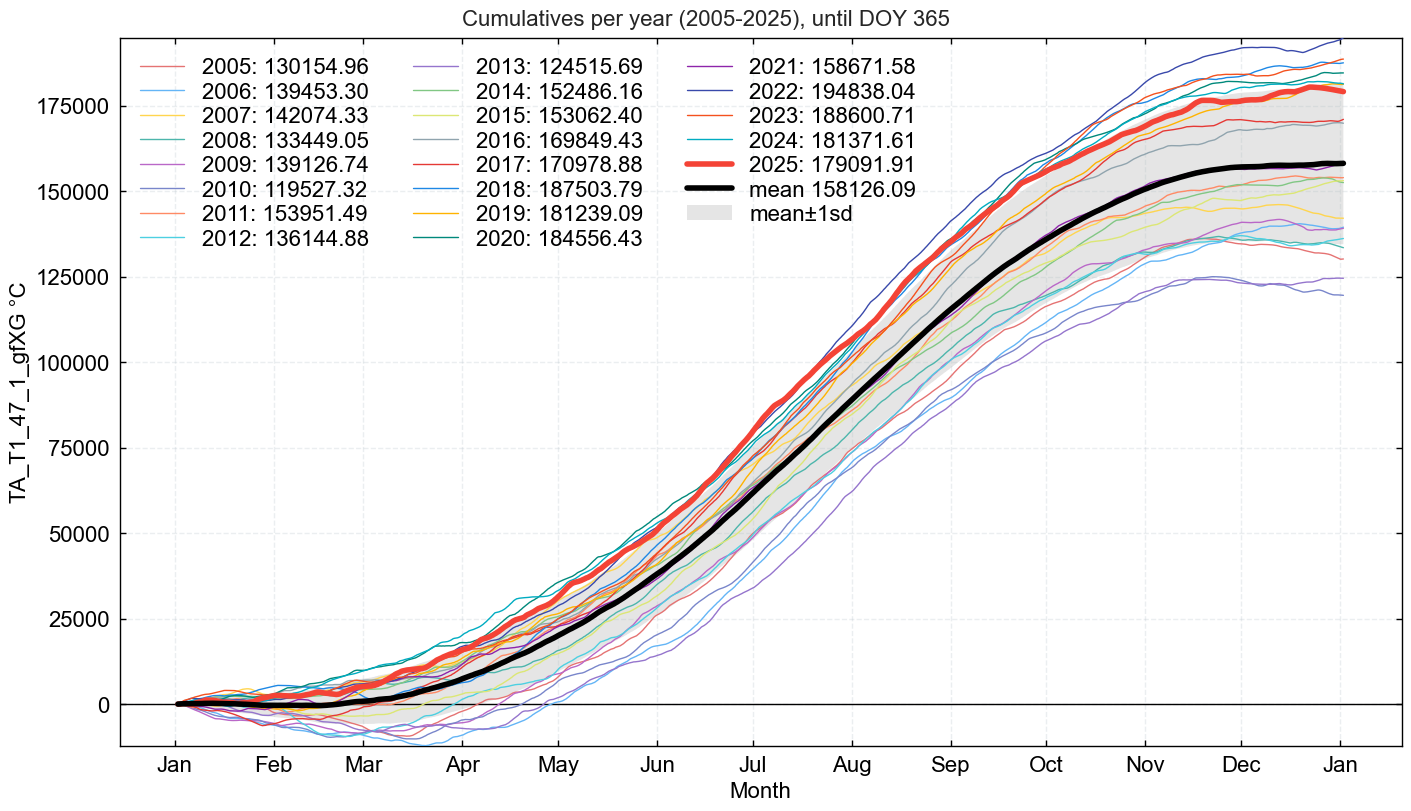

In [22]:
CumulativeYear(
    series=series,
    series_units=units,
    start_year=2005,
    end_year=2025,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=2025).plot(highlight_year_color='#F44336');

</br>

# Long-term anomalies

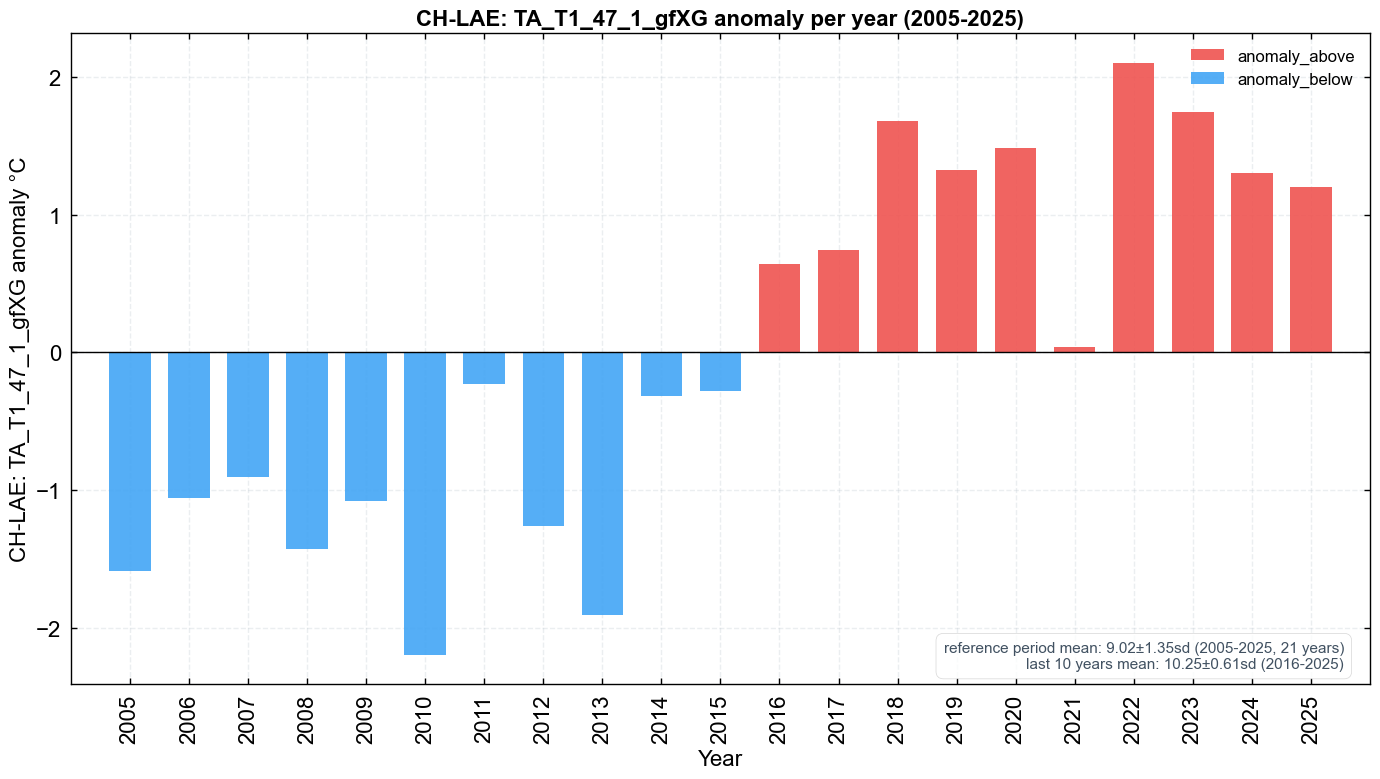

In [23]:
series_yearly_mean = series.resample('YE').mean()
series_yearly_mean.index = series_yearly_mean.index.year
series_label = f"CH-LAE: {varname}"
LongtermAnomaliesYear(series=series_yearly_mean,
                      series_label=series_label,
                      series_units=units,
                      reference_start_year=2005,
                      reference_end_year=2025).plot()

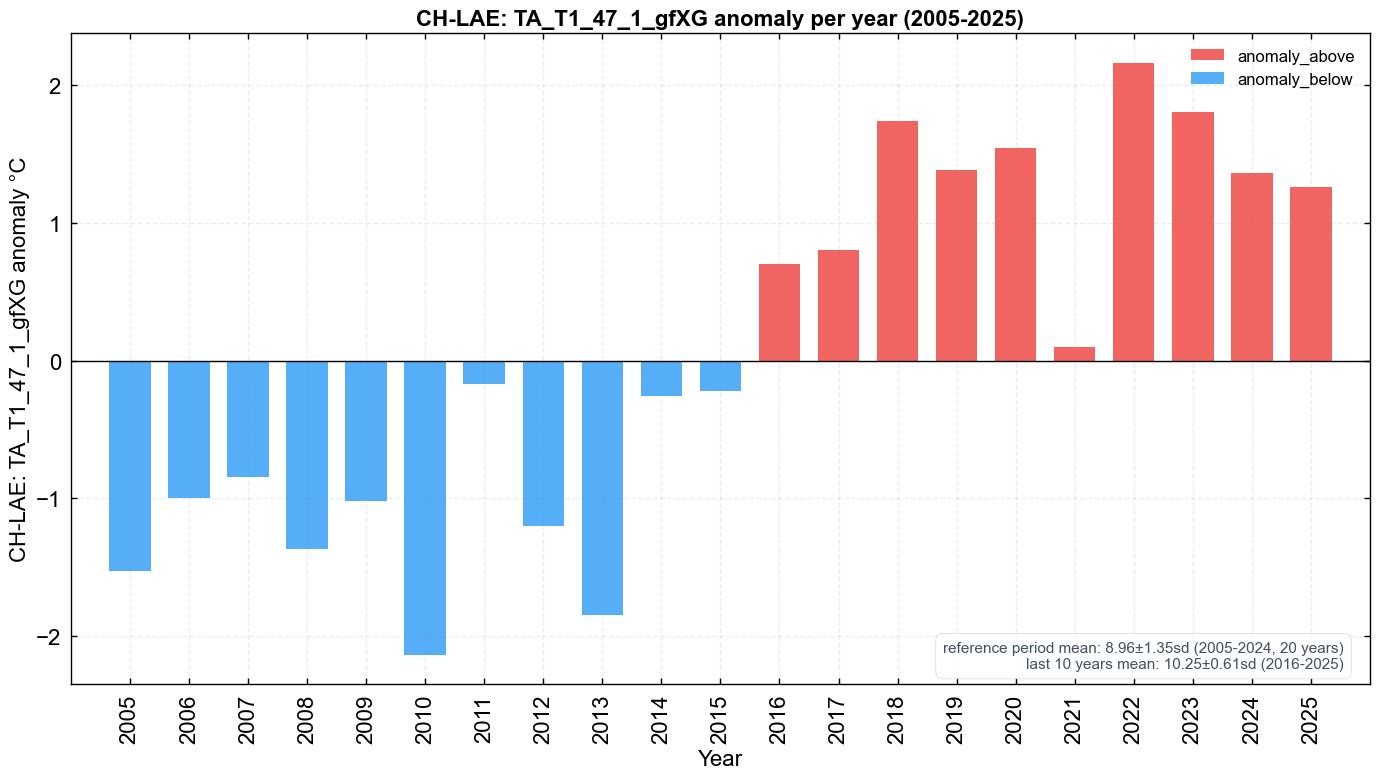

In [24]:
series_yearly_mean = series.resample('YE').mean()
series_yearly_mean.index = series_yearly_mean.index.year
series_label = f"CH-LAE: {varname}"
LongtermAnomaliesYear(series=series_yearly_mean,
                      series_label=series_label,
                      series_units=units,
                      reference_start_year=2005,
                      reference_end_year=2024).plot()

</br>

# End of notebook

In [25]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-07-20 03:13:04
